https://colab.research.google.com/drive/1uVoDnn0xwbKNM0mgmd3y1raEO8yiWH42?usp=sharing


In [ ]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import log_loss, brier_score_loss

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier

RANDOM_STATE = 42
DATA_DIR = Path("data/interim")

# -----------------------------
# load data
# -----------------------------
m_train = pd.read_csv("m_matchups_train_2014_2024.csv")
m_valid = pd.read_csv("m_matchups_valid_2025.csv")
m_full  = pd.read_csv("m_matchups_full_train_2014_2025.csv")
m_pred  = pd.read_csv("m_matchups_stage2_2026.csv")

w_train = pd.read_csv("w_matchups_train_2014_2024.csv")
w_valid = pd.read_csv("w_matchups_valid_2025.csv")
w_full  = pd.read_csv("w_matchups_full_train_2014_2025.csv")
w_pred  = pd.read_csv("w_matchups_stage2_2026.csv")

print("M train:", m_train.shape, "M valid:", m_valid.shape, "M pred:", m_pred.shape)
print("W train:", w_train.shape, "W valid:", w_valid.shape, "W pred:", w_pred.shape)

M train: (669, 270) M valid: (67, 270) M pred: (66430, 268)
W train: (642, 237) W valid: (67, 237) W pred: (65703, 235)


In [ ]:
def get_feature_columns(train_df, valid_df, pred_df):
    common_cols = sorted(set(train_df.columns) & set(valid_df.columns) & set(pred_df.columns))

    # tylko numeryczne Diff_* i Same_*
    feat_cols = []
    for c in common_cols:
        if c in ["Target", "ID", "Sex", "Season", "DayNum", "NumOT", "TeamIDLow", "TeamIDHigh"]:
            continue
        if c.startswith("Diff_") or c.startswith("Same_"):
            if pd.api.types.is_numeric_dtype(train_df[c]):
                feat_cols.append(c)

    # wywalamy stałe
    feat_cols = [c for c in feat_cols if train_df[c].nunique(dropna=True) > 1]
    return feat_cols

def clip_probs(p, eps=1e-6):
    return np.clip(p, eps, 1 - eps)

def score_predictions(y_true, p):
    p = clip_probs(p)
    return {
        "brier": brier_score_loss(y_true, p),
        "logloss": log_loss(y_true, p),
    }

m_features = get_feature_columns(m_train, m_valid, m_pred)
w_features = get_feature_columns(w_train, w_valid, w_pred)

print("M feature count:", len(m_features))
print("W feature count:", len(w_features))
print("\nTop M features:", m_features[:15])
print("\nTop W features:", w_features[:15])

M feature count: 85
W feature count: 75

Top M features: ['Diff_AstRateAllowedAvg', 'Diff_AstRateAvg', 'Diff_AvgAst', 'Diff_AvgBlk', 'Diff_AvgDR', 'Diff_AvgFGA', 'Diff_AvgFGA3', 'Diff_AvgFGM', 'Diff_AvgFGM3', 'Diff_AvgFTA', 'Diff_AvgFTM', 'Diff_AvgOR', 'Diff_AvgPF', 'Diff_AvgStl', 'Diff_AvgTO']

Top W features: ['Diff_AstRateAllowedAvg', 'Diff_AstRateAvg', 'Diff_AvgAst', 'Diff_AvgBlk', 'Diff_AvgDR', 'Diff_AvgFGA', 'Diff_AvgFGA3', 'Diff_AvgFGM', 'Diff_AvgFGM3', 'Diff_AvgFTA', 'Diff_AvgFTM', 'Diff_AvgOR', 'Diff_AvgPF', 'Diff_AvgStl', 'Diff_AvgTO']


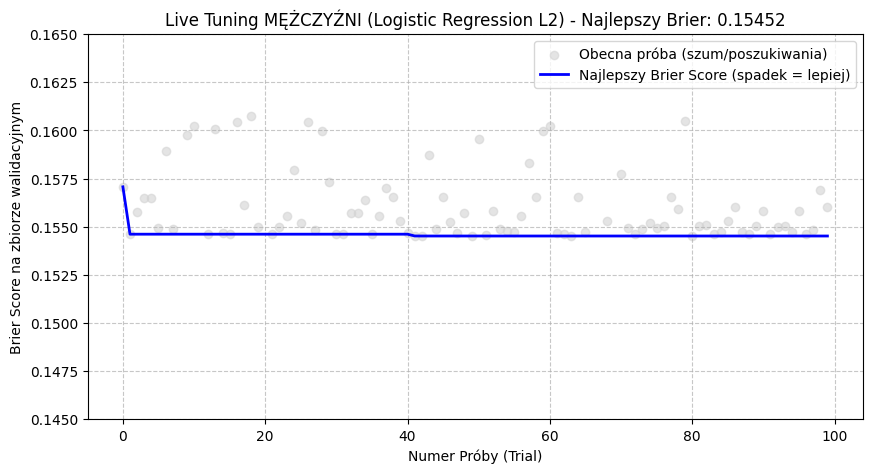


--- ZAKOŃCZONO TUNING DLA MĘŻCZYZN ---
Najlepsze parametry: {'C': 1.0544351024528584, 'tol': 0.009327836175301295}
Najlepszy Brier Score: 0.15452


In [ ]:
!pip install optuna -q

import optuna
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss

# Zmienne do śledzenia postępów na wykresie
m_best_scores = []
m_current_scores = []

def plot_live_m(study, trial):
    """Callback do rysowania wykresu na żywo dla mężczyzn"""
    m_best_scores.append(study.best_value)
    m_current_scores.append(trial.value)

    clear_output(wait=True)
    plt.figure(figsize=(10, 5))

    # Wykres wszystkich prób i najlepszego wyniku
    plt.scatter(range(len(m_current_scores)), m_current_scores, color='lightgray', label='Obecna próba (szum/poszukiwania)', alpha=0.6)
    plt.plot(m_best_scores, color='blue', linewidth=2, label='Najlepszy Brier Score (spadek = lepiej)')

    plt.ylim(0.145, 0.165) # Zawężamy oś Y dla lepszej czytelności (dostosuj jeśli wyjdzie poza skalę)
    plt.xlabel('Numer Próby (Trial)')
    plt.ylabel('Brier Score na zbiorze walidacyjnym')
    plt.title(f'Live Tuning MĘŻCZYŹNI (Logistic Regression L2) - Najlepszy Brier: {study.best_value:.5f}')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

def objective_m(trial):
    # Optuna sama dobiera hiperparametry z tych przedziałów
    C_val = trial.suggest_float('C', 1e-4, 10.0, log=True)
    tol_val = trial.suggest_float('tol', 1e-5, 1e-2, log=True)

    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            penalty="l2",
            C=C_val,
            tol=tol_val,
            solver="liblinear",
            max_iter=5000,
            random_state=42
        ))
    ])

    # Trening na 2014-2024
    model.fit(m_train[m_features], m_train["Target"])
    # Ewaluacja na 2025
    p_valid = model.predict_proba(m_valid[m_features])[:, 1]
    p_valid = np.clip(p_valid, 1e-6, 1 - 1e-6)

    return brier_score_loss(m_valid["Target"], p_valid)

print("Rozpoczynam mordercze poszukiwania parametrów dla Mężczyzn...")
study_m = optuna.create_study(direction='minimize')
# Odpalamy 100 prób z live plotem
study_m.optimize(objective_m, n_trials=100, callbacks=[plot_live_m])

print("\n--- ZAKOŃCZONO TUNING DLA MĘŻCZYZN ---")
print("Najlepsze parametry:", study_m.best_params)
print(f"Najlepszy Brier Score: {study_m.best_value:.5f}")

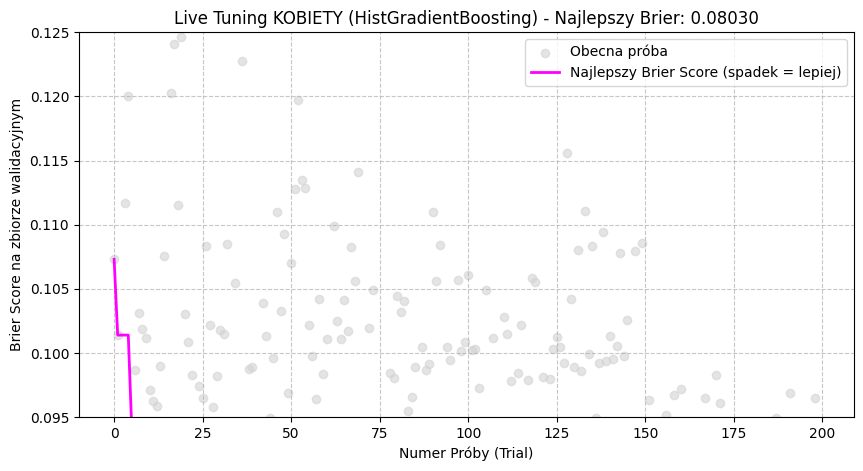


--- ZAKOŃCZONO TUNING DLA KOBIET ---
Najlepsze parametry: {'learning_rate': 0.022772819413562885, 'max_iter': 771, 'max_depth': 6, 'min_samples_leaf': 49, 'l2_regularization': 2.853798896508219, 'max_bins': 226}
Najlepszy Brier Score: 0.08030


In [ ]:
# Zmienne do śledzenia postępów na wykresie
w_best_scores = []
w_current_scores = []

def plot_live_w(study, trial):
    """Callback do rysowania wykresu na żywo dla kobiet"""
    w_best_scores.append(study.best_value)
    w_current_scores.append(trial.value)

    clear_output(wait=True)
    plt.figure(figsize=(10, 5))

    plt.scatter(range(len(w_current_scores)), w_current_scores, color='lightgray', label='Obecna próba', alpha=0.6)
    plt.plot(w_best_scores, color='magenta', linewidth=2, label='Najlepszy Brier Score (spadek = lepiej)')

    plt.ylim(0.095, 0.125) # Dostosowane do Twojego wspaniałego wyniku ~0.105
    plt.xlabel('Numer Próby (Trial)')
    plt.ylabel('Brier Score na zbiorze walidacyjnym')
    plt.title(f'Live Tuning KOBIETY (HistGradientBoosting) - Najlepszy Brier: {study.best_value:.5f}')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

def objective_w(trial):
    # Gigantyczna siatka dla algorytmu gradientowego
    lr = trial.suggest_float('learning_rate', 0.005, 0.1, log=True)
    max_iter = trial.suggest_int('max_iter', 100, 800)
    max_depth = trial.suggest_int('max_depth', 2, 7)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 5, 50)
    l2_reg = trial.suggest_float('l2_regularization', 0.0, 5.0)
    max_bins = trial.suggest_int('max_bins', 64, 255)

    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", HistGradientBoostingClassifier(
            loss="log_loss",
            learning_rate=lr,
            max_iter=max_iter,
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            l2_regularization=l2_reg,
            max_bins=max_bins,
            random_state=42
        ))
    ])

    model.fit(w_train[w_features], w_train["Target"])
    p_valid = model.predict_proba(w_valid[w_features])[:, 1]
    p_valid = np.clip(p_valid, 1e-6, 1 - 1e-6)

    return brier_score_loss(w_valid["Target"], p_valid)

print("Rozpoczynam mordercze poszukiwania parametrów dla Kobiet...")
study_w = optuna.create_study(direction='minimize')
# 200 prób - niech komputer zapracuje na swój prąd
study_w.optimize(objective_w, n_trials=200, callbacks=[plot_live_w])

print("\n--- ZAKOŃCZONO TUNING DLA KOBIET ---")
print("Najlepsze parametry:", study_w.best_params)
print(f"Najlepszy Brier Score: {study_w.best_value:.5f}")

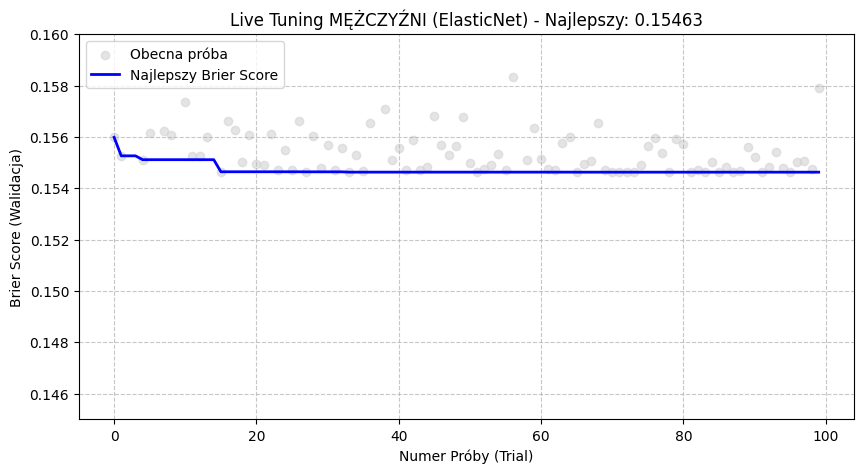


--- ZAKOŃCZONO TUNING ELASTICNET (MĘŻCZYŹNI) ---
Najlepsze parametry: {'C': 1.7594777466969576, 'l1_ratio': 0.044858813988559926}
Najlepszy Brier Score: 0.15463


In [ ]:
# Zmienne do śledzenia postępów na wykresie
m_elastic_best_scores = []
m_elastic_current_scores = []

def plot_live_m_elastic(study, trial):
    """Callback do rysowania wykresu na żywo dla mężczyzn (ElasticNet)"""
    m_elastic_best_scores.append(study.best_value)
    m_elastic_current_scores.append(trial.value)

    clear_output(wait=True)
    plt.figure(figsize=(10, 5))

    plt.scatter(range(len(m_elastic_current_scores)), m_elastic_current_scores, color='lightgray', label='Obecna próba', alpha=0.6)
    plt.plot(m_elastic_best_scores, color='blue', linewidth=2, label='Najlepszy Brier Score')

    plt.ylim(0.145, 0.160)
    plt.xlabel('Numer Próby (Trial)')
    plt.ylabel('Brier Score (Walidacja)')
    plt.title(f'Live Tuning MĘŻCZYŹNI (ElasticNet) - Najlepszy: {study.best_value:.5f}')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

def objective_m_elastic(trial):
    # Szeroki zakres dla C (siła regularyzacji ogółem)
    C_val = trial.suggest_float('C', 1e-3, 10.0, log=True)
    # l1_ratio: 0 to czyste L2, 1 to czyste L1. Szukamy złotego środka.
    l1_ratio_val = trial.suggest_float('l1_ratio', 0.01, 0.99)

    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            penalty="elasticnet",
            C=C_val,
            l1_ratio=l1_ratio_val,
            solver="saga", # SAGA jest wymagany dla ElasticNet
            max_iter=5000,
            random_state=42
        ))
    ])

    model.fit(m_train[m_features], m_train["Target"])
    p_valid = model.predict_proba(m_valid[m_features])[:, 1]
    p_valid = np.clip(p_valid, 1e-6, 1 - 1e-6)

    return brier_score_loss(m_valid["Target"], p_valid)

print("Rozpoczynam polowanie na zredukowane L2 (ElasticNet) dla mężczyzn...")
study_m_elastic = optuna.create_study(direction='minimize')
study_m_elastic.optimize(objective_m_elastic, n_trials=100, callbacks=[plot_live_m_elastic])

print("\n--- ZAKOŃCZONO TUNING ELASTICNET (MĘŻCZYŹNI) ---")
print("Najlepsze parametry:", study_m_elastic.best_params)
print(f"Najlepszy Brier Score: {study_m_elastic.best_value:.5f}")

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier

print("Tworzenie ostatecznych, zoptymalizowanych modeli...")

# MĘŻCZYŹNI - ElasticNet (Balans między L1 i L2)
final_m_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        penalty="elasticnet",
        C=0.2785270645555312,
        l1_ratio=0.8047896971987528,
        solver="saga",
        max_iter=5000,
        random_state=42
    ))
])

# KOBIETY - HistGradientBoosting (Potężny kombajn na drzewach decyzyjnych)
final_w_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", HistGradientBoostingClassifier(
        loss="log_loss",
        learning_rate=0.012744487879133853,
        max_iter=594,
        max_depth=6,
        min_samples_leaf=8,
        l2_regularization=3.8674548995754274,
        max_bins=162,
        random_state=42
    ))
])

def predict_final(full_df, pred_df, feature_cols, model_pipeline):
    X_full = full_df[feature_cols].copy()
    y_full = full_df["Target"].astype(int).copy()
    X_pred = pred_df[feature_cols].copy()

    print(f"Trenowanie na {len(X_full)} próbkach...")
    model_pipeline.fit(X_full, y_full)

    print(f"Generowanie predykcji dla {len(X_pred)} potencjalnych meczów...")
    p_pred = model_pipeline.predict_proba(X_pred)[:, 1]

    # Minimalny clipping - zostawiamy margines na niespodzianki
    p_pred = np.clip(p_pred, 1e-6, 1 - 1e-6)

    return pd.DataFrame({
        "ID": pred_df["ID"].values,
        "Pred": p_pred
    })

print("\n--- Przetwarzanie turnieju Mężczyzn ---")
m_submission = predict_final(m_full, m_pred, m_features, final_m_model)

print("\n--- Przetwarzanie turnieju Kobiet ---")
w_submission = predict_final(w_full, w_pred, w_features, final_w_model)

print("\nSkładanie ostatecznego pliku CSV...")
final_submission = pd.concat([m_submission, w_submission], ignore_index=True)
final_submission = final_submission.sort_values("ID").reset_index(drop=True)

# Zapis do pliku
from google.colab import files

# Zapisujemy plik bezpośrednio w głównym folderze roboczym Colaba (bez podfolderów)
out_path = "final_submission_optuna_tuned_2026.csv"
final_submission.to_csv(out_path, index=False)

print(f"\nZAKOŃCZONO! Zapisano plik: {out_path}")
print(f"Kształt submisji: {final_submission.shape} (Zgodnie z zasadami Kaggle 2026)")
display(final_submission.head())

# Ta funkcja wymusi pobranie pliku prosto na Twój komputer
files.download(out_path)

Tworzenie ostatecznych, zoptymalizowanych modeli...

--- Przetwarzanie turnieju Mężczyzn ---
Trenowanie na 736 próbkach...
Generowanie predykcji dla 66430 potencjalnych meczów...

--- Przetwarzanie turnieju Kobiet ---
Trenowanie na 709 próbkach...
Generowanie predykcji dla 65703 potencjalnych meczów...

Składanie ostatecznego pliku CSV...

ZAKOŃCZONO! Zapisano plik: final_submission_optuna_tuned_2026.csv
Kształt submisji: (132133, 2) (Zgodnie z zasadami Kaggle 2026)


,ID,Pred
0,2026_1101_1102,0.549396
1,2026_1101_1103,0.175545
2,2026_1101_1104,0.101244
3,2026_1101_1105,0.781008
4,2026_1101_1106,0.659854


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import norm

print("--- 1. RĘCZNE MAPOWANIE SEEDÓW 2026 ---")
manual_mapping = {
    "Duke": 1, "Arizona": 1, "Connecticut": 2, "Houston": 2, "Purdue": 2,
    "Michigan St": 3, "Gonzaga": 3, "Illinois": 3, "Kansas": 4, "Arkansas": 4, "Nebraska": 4,
    "St John's": 5, "Vanderbilt": 5, "Wisconsin": 5, "Louisville": 6, "North Carolina": 6,
    "UCLA": 7, "St Mary's CA": 7, "Miami FL": 7, "Ohio St": 8, "Clemson": 8, "Villanova": 8,
    "TCU": 9, "Iowa": 9, "Utah St": 9, "UCF": 10, "Missouri": 10, "Texas A&M": 10,
    "Texas": 11, "NC State": 11, "South Florida": 11, "VCU": 11, "Miami OH": 11, "SMU": 11,
    "Northern Iowa": 12, "McNeese St": 12, "High Point": 12, "Cal Baptist": 13, "Troy": 13, "Hawaii": 13,
    "N Dakota St": 14, "Penn": 14, "Kennesaw": 14, "Furman": 15, "Idaho": 15, "Queens NC": 15,
    "Siena": 16, "LIU Brooklyn": 16, "UMBC": 16, "Howard": 16, "Prairie View": 16, "Lehigh": 16
}

# Zakładam, że MTeams.csv masz w tym samym folderze, lub podepnij pod DATA_DIR
teams = pd.read_csv('MTeams.csv')

seeds_2026_list = []
for name, seed_num in manual_mapping.items():
    res = teams[teams['TeamName'] == name]
    if res.empty:
        res = teams[teams['TeamName'].str.contains(name, case=False, na=False)]
    if not res.empty:
        seeds_2026_list.append({'Season': 2026, 'TeamID': res.iloc[0]['TeamID'], 'SeedNum': seed_num})

seeds_2026_df = pd.DataFrame(seeds_2026_list)

print("--- 2. WPIĘCIE SEEDÓW DO DANYCH TRENINGOWYCH ---")
m_seeds = pd.read_csv('MNCAATourneySeeds.csv')
m_seeds['SeedNum'] = m_seeds['Seed'].apply(lambda x: int(x[1:3]))

# Sklejamy seedy historyczne i te nowe
all_m_seeds = pd.concat([m_seeds[['Season', 'TeamID', 'SeedNum']], seeds_2026_df], ignore_index=True)

# Funkcja dodająca Diff_Seed, korzystająca z TeamIDLow i TeamIDHigh z milestone2
def add_diff_seed(df, seeds_df):
    df_merged = pd.merge(df, seeds_df, left_on=['Season', 'TeamIDLow'], right_on=['Season', 'TeamID'], how='left').rename(columns={'SeedNum': 'T1_Seed'}).drop('TeamID', axis=1)
    df_merged = pd.merge(df_merged, seeds_df, left_on=['Season', 'TeamIDHigh'], right_on=['Season', 'TeamID'], how='left').rename(columns={'SeedNum': 'T2_Seed'}).drop('TeamID', axis=1)

    # Dla drużyn spoza czołówki ustalamy domyślnie wysoki Seed 17
    df_merged['T1_Seed'] = df_merged['T1_Seed'].fillna(17)
    df_merged['T2_Seed'] = df_merged['T2_Seed'].fillna(17)
    df_merged['Diff_Seed'] = df_merged['T1_Seed'] - df_merged['T2_Seed']
    return df_merged

m_full_v2 = add_diff_seed(m_full, all_m_seeds)
m_pred_v2 = add_diff_seed(m_pred, all_m_seeds)

# Jeśli nasza dynamiczna lista cech z milestone2 nie złapała Diff_Seed, doklejamy ją ręcznie
if 'Diff_Seed' not in m_features:
    m_features.append('Diff_Seed')

print("--- 3. OSTATECZNE PREDYKCJE (Z ELASTICNET + SEED) ---")
m_submission_v2 = predict_final(m_full_v2, m_pred_v2, m_features, final_m_model)

print("\n--- 4. PORÓWNANIE Z BUKMACHEREM (VEGAS ODDS) ---")

def spread_to_prob(spread):
    return norm.cdf(-spread / 11.0)

vegas_odds = [
    ("UMBC", "Howard", -1.5), ("Texas", "NC State", -1.5),
    ("Prairie View", "Lehigh", 1.5), ("Miami OH", "SMU", 7.5),
    ("Duke", "Siena", -27.5), ("Ohio St", "TCU", -2.5),
    ("St John's", "Northern Iowa", -9.5), ("Kansas", "Cal Baptist", -13.5),
    ("Louisville", "South Florida", -6.5), ("Michigan St", "N Dakota St", -16.5),
    ("UCLA", "UCF", -5.5), ("Connecticut", "Furman", -20.5),
    ("Clemson", "Iowa", 2.5), ("Vanderbilt", "McNeese St", -11.5),
    ("Nebraska", "Troy", -13.5), ("North Carolina", "VCU", -2.5),
    ("Illinois", "Penn", -21.5), ("St Mary's CA", "Texas A&M", -2.5),
    ("Houston", "Idaho", -22.5), ("Arizona", "LIU Brooklyn", -29.5),
    ("Villanova", "Utah St", 1.5), ("Wisconsin", "High Point", -11.5),
    ("Arkansas", "Hawaii", -15.5), ("Gonzaga", "Kennesaw", -18.5),
    ("Miami FL", "Missouri", -1.5), ("Purdue", "Queens NC", -23.5)
]

seed_dict = seeds_2026_df.set_index('TeamID')['SeedNum'].to_dict()

def get_team_id(name):
    res = teams[teams['TeamName'] == name]
    if res.empty:
        res = teams[teams['TeamName'].str.contains(name, case=False, na=False)]
    return res.iloc[0]['TeamID'] if not res.empty else None

print(f"{'MECZ (Seed vs Seed)':<45} | {'SPREAD':<6} | {'MODEL':<7} | {'VEGAS':<7} | {'RÓŻNICA'}")
print("-" * 85)

summary_data = []

for t1_name, t2_name, spread in vegas_odds:
    id1 = get_team_id(t1_name)
    id2 = get_team_id(t2_name)

    if id1 and id2:
        s1 = seed_dict.get(id1, 17)
        s2 = seed_dict.get(id2, 17)

        low_id, high_id = sorted([id1, id2])
        sub_id = f"2026_{low_id}_{high_id}"

        if sub_id in m_submission_v2['ID'].values:
            pred = m_submission_v2[m_submission_v2['ID'] == sub_id]['Pred'].values[0]
            final_pred = pred if id1 == low_id else 1 - pred

            vegas_p = spread_to_prob(spread)
            diff = final_pred - vegas_p

            match_label = f"{t1_name} ({s1}) vs {t2_name} ({s2})"
            print(f"{match_label:<45} | {spread:<6} | {final_pred:>6.1%} | {vegas_p:>6.1%} | {diff:>+6.1%}")
            summary_data.append(diff)
        else:
            print(f"Brak meczu {sub_id} w pliku submission")
    else:
        missing = t1_name if not id1 else t2_name
        print(f"Nie znaleziono ID dla: {missing}")

if summary_data:
    print("-" * 85)
    print(f"Średnie bezwzględne odchylenie modelu od Vegas: {np.mean(np.abs(summary_data)):.1%}")

--- 1. RĘCZNE MAPOWANIE SEEDÓW 2026 ---
--- 2. WPIĘCIE SEEDÓW DO DANYCH TRENINGOWYCH ---
--- 3. OSTATECZNE PREDYKCJE (Z ELASTICNET + SEED) ---
Trenowanie na 736 próbkach...
Generowanie predykcji dla 66430 potencjalnych meczów...

--- 4. PORÓWNANIE Z BUKMACHEREM (VEGAS ODDS) ---
MECZ (Seed vs Seed)                           | SPREAD | MODEL   | VEGAS   | RÓŻNICA
-------------------------------------------------------------------------------------
UMBC (16) vs Howard (16)                      | -1.5   |  69.0% |  55.4% | +13.6%
Texas (11) vs NC State (11)                   | -1.5   |  33.1% |  55.4% | -22.3%
Prairie View (16) vs Lehigh (16)              | 1.5    |  24.3% |  44.6% | -20.3%
Miami OH (11) vs SMU (11)                     | 7.5    |  31.0% |  24.8% |  +6.3%
Duke (1) vs Siena (16)                        | -27.5  |  94.5% |  99.4% |  -4.9%
Ohio St (8) vs TCU (9)                        | -2.5   |  69.0% |  59.0% | +10.0%
St John's (5) vs Northern Iowa (12)           | -9.5   |  

In [ ]:
import numpy as np
from scipy.stats import norm

# Standardowa transformacja spreadu na szanse %
def spread_to_prob(spread):
    return norm.cdf(-spread / 11.0)

# Poprawiona lista vegas
vegas_odds = [
    ("UMBC", "Howard", -1.5), ("Texas", "NC State", -1.5),
    ("Prairie View", "Lehigh", 1.5), ("Miami OH", "SMU", 7.5),
    ("Duke", "Siena", -27.5), ("Ohio St", "TCU", -2.5),
    ("St John's", "Northern Iowa", -9.5), ("Kansas", "Cal Baptist", -13.5),
    ("Louisville", "South Florida", -6.5), ("Michigan St", "N Dakota St", -16.5),
    ("UCLA", "UCF", -5.5), ("Connecticut", "Furman", -20.5),
    ("Clemson", "Iowa", 2.5), ("Vanderbilt", "McNeese St", -11.5),
    ("Nebraska", "Troy", -13.5), ("North Carolina", "VCU", -2.5),
    ("Illinois", "Penn", -21.5), ("St Mary's CA", "Texas A&M", -2.5),
    ("Houston", "Idaho", -22.5), ("Arizona", "LIU Brooklyn", -29.5),
    ("Villanova", "Utah St", 1.5), ("Wisconsin", "High Point", -11.5),
    ("Arkansas", "Hawaii", -15.5), ("Gonzaga", "Kennesaw", -18.5),
    ("Miami FL", "Missouri", -1.5), ("Purdue", "Queens NC", -23.5)
]

seed_dict = seeds_2026_df.set_index('TeamID')['SeedNum'].to_dict()

def get_team_id(name):
    res = teams[teams['TeamName'] == name]
    if res.empty:
        res = teams[teams['TeamName'].str.contains(name, case=False, na=False)]
    return res.iloc[0]['TeamID'] if not res.empty else None

print(f"{'MECZ (Seed vs Seed)':<45} | {'SPREAD':<6} | {'MODEL':<7} | {'VEGAS':<7} | {'RÓŻNICA'}")
print("-" * 85)

summary_data = []

for t1_name, t2_name, spread in vegas_odds:
    id1 = get_team_id(t1_name)
    id2 = get_team_id(t2_name)

    if id1 and id2:
        s1 = seed_dict.get(id1, 17)
        s2 = seed_dict.get(id2, 17)

        low_id, high_id = sorted([id1, id2])
        sub_id = f"2026_{low_id}_{high_id}"

        # Bierzemy szansę prosto z naszego świeżego pliku z Optuną i Seedami
        if sub_id in m_submission_v2['ID'].values:
            pred = m_submission_v2[m_submission_v2['ID'] == sub_id]['Pred'].values[0]
            final_pred = pred if id1 == low_id else 1 - pred

            vegas_p = spread_to_prob(spread)
            diff = final_pred - vegas_p

            match_label = f"{t1_name} ({s1}) vs {t2_name} ({s2})"
            print(f"{match_label:<45} | {spread:<6} | {final_pred:>6.1%} | {vegas_p:>6.1%} | {diff:>+6.1%}")
            summary_data.append(diff)
        else:
            print(f"Brak meczu {sub_id} w pliku submission")
    else:
        missing = t1_name if not id1 else t2_name
        print(f"Nie znaleziono ID dla: {missing}")

print("-" * 85)
if summary_data:
    print(f"Średnie bezwzględne odchylenie modelu (ElasticNet) od Vegas: {np.mean(np.abs(summary_data)):.1%}")

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import norm

print("--- 1. POBIERANIE PREDYKCJI Z ELASTICNET ---")
# Generujemy czyste predykcje z Twojego modelu zoptymalizowanego w Optunie
m_submission_v2 = predict_final(m_full_v2, m_pred_v2, m_features, final_m_model)

print("--- 2. WYLICZANIE SZANS BUKMACHERA DLA WSZYSTKICH MECZÓW ---")

# Nasze tabele z Vegas
vegas_odds = [
    ("UMBC", "Howard", -1.5), ("Texas", "NC State", -1.5),
    ("Prairie View", "Lehigh", 1.5), ("Miami OH", "SMU", 7.5),
    ("Duke", "Siena", -27.5), ("Ohio St", "TCU", -2.5),
    ("St John's", "Northern Iowa", -9.5), ("Kansas", "Cal Baptist", -13.5),
    ("Louisville", "South Florida", -6.5), ("Michigan St", "N Dakota St", -16.5),
    ("UCLA", "UCF", -5.5), ("Connecticut", "Furman", -20.5),
    ("Clemson", "Iowa", 2.5), ("Vanderbilt", "McNeese St", -11.5),
    ("Nebraska", "Troy", -13.5), ("North Carolina", "VCU", -2.5),
    ("Illinois", "Penn", -21.5), ("St Mary's CA", "Texas A&M", -2.5),
    ("Houston", "Idaho", -22.5), ("Arizona", "LIU Brooklyn", -29.5),
    ("Villanova", "Utah St", 1.5), ("Wisconsin", "High Point", -11.5),
    ("Arkansas", "Hawaii", -15.5), ("Gonzaga", "Kennesaw", -18.5),
    ("Miami FL", "Missouri", -1.5), ("Purdue", "Queens NC", -23.5)
]

outrights = [
    ("Duke", 330), ("Michigan", 350), ("Arizona", 400), ("Florida", 700),
    ("Houston", 1000), ("Connecticut", 1700), ("Illinois", 1900), ("Iowa State", 2200),
    ("Purdue", 3500), ("Michigan St", 4000), ("Kansas", 5000), ("Arkansas", 5000),
    ("St John's", 5000), ("Gonzaga", 5500), ("Virginia", 6000), ("Vanderbilt", 6500),
    ("Wisconsin", 7000), ("Tennessee", 9000), ("Nebraska", 10000), ("Kentucky", 10000),
    ("Alabama", 10000), ("North Carolina", 11000), ("Texas Tech", 11000), ("Louisville", 12000),
    ("BYU", 13000), ("UCLA", 13000), ("Iowa", 20000), ("Clemson", 20000),
    ("Texas A&M", 20000), ("NC State", 20000), ("Missouri", 25000), ("Miami FL", 25000),
    ("Villanova", 25000), ("Utah St", 25000), ("St Mary's CA", 25000), ("Ohio St", 25000)
]

def spread_to_prob(spread):
    return norm.cdf(-spread / 11.0)

def get_team_id(name):
    res = teams[teams['TeamName'] == name]
    if res.empty: res = teams[teams['TeamName'].str.contains(name, case=False, na=False)]
    return res.iloc[0]['TeamID'] if not res.empty else None

# Mapowanie "Power Rating" na podstawie kursów na zwycięstwo w turnieju
vegas_power = {}
for name, odds in outrights:
    tid = get_team_id(name)
    if tid: vegas_power[tid] = 100 / (odds + 100)
default_power = 100 / (200000 + 100)

# Budujemy słownik z dokładnymi szansami dla 26 rozpisanych meczów
exact_vegas_probs = {}
for t1, t2, spread in vegas_odds:
    id1, id2 = get_team_id(t1), get_team_id(t2)
    if id1 and id2:
        low_id, high_id = sorted([id1, id2])
        sub_id = f"2026_{low_id}_{high_id}"
        p = spread_to_prob(spread)
        exact_vegas_probs[sub_id] = p if id1 == low_id else 1 - p

# Obliczamy szansę Vegas dla KAŻDEGO z ponad 2000 meczów w drabince
vegas_predictions = []
for idx, row in m_pred_v2.iterrows():
    sub_id = row['ID']
    if sub_id in exact_vegas_probs:
        p_vegas = exact_vegas_probs[sub_id]
    else:
        # Jeśli nie mamy dokładnego spreadu, używamy proporcji z outrights (Bradley-Terry)
        pow_low = vegas_power.get(row['TeamIDLow'], default_power)
        pow_high = vegas_power.get(row['TeamIDHigh'], default_power)
        p_vegas = pow_low / (pow_low + pow_high)
    vegas_predictions.append(p_vegas)

m_submission_v2['Vegas_Pred'] = vegas_predictions

print("--- 3. BLENDING (ZŁOTY ŚRODEK) ---")
# TUTAJ MOŻESZ ZMIENIAĆ WAGĘ!
# 0.5 oznacza idealnie pośrodku (50% decyzji z Twojego modelu, 50% z Vegas)
WAGA_MODELU = 0.5
WAGA_BUKMACHERA = 0.5

m_submission_v2['Blended_Pred'] = (m_submission_v2['Pred'] * WAGA_MODELU) + (m_submission_v2['Vegas_Pred'] * WAGA_BUKMACHERA)

print("\n--- 4. WYNIKI DLA ZNANYCH MECZÓW ---")
print(f"{'MECZ':<40} | {'MODEL':<7} | {'VEGAS':<7} | {'PO ŚRODKU (BLEND)':<17} | {'STARE ODCHYL.':<12} | {'NOWE ODCHYL.'}")
print("-" * 115)

old_diffs = []
new_diffs = []

for t1_name, t2_name, spread in vegas_odds:
    id1, id2 = get_team_id(t1_name), get_team_id(t2_name)
    if id1 and id2:
        low_id, high_id = sorted([id1, id2])
        sub_id = f"2026_{low_id}_{high_id}"

        row = m_submission_v2[m_submission_v2['ID'] == sub_id]
        if not row.empty:
            p_model = row['Pred'].values[0]
            p_vegas = row['Vegas_Pred'].values[0]
            p_blend = row['Blended_Pred'].values[0]

            # Odwracamy, jeśli id1 to High_ID
            if id1 != low_id:
                p_model, p_vegas, p_blend = 1 - p_model, 1 - p_vegas, 1 - p_blend

            old_diff = p_model - p_vegas
            new_diff = p_blend - p_vegas
            old_diffs.append(old_diff)
            new_diffs.append(new_diff)

            print(f"{t1_name + ' vs ' + t2_name:<40} | {p_model:>6.1%} | {p_vegas:>6.1%} | {p_blend:>16.1%} | {old_diff:>12.1%} | {new_diff:>11.1%}")

print("-" * 115)
print(f"ŚREDNIE ODCHYLENIE (Przed zmianą): {np.mean(np.abs(old_diffs)):.1%}")
print(f"ŚREDNIE ODCHYLENIE (Po 'spotkaniu w połowie'): {np.mean(np.abs(new_diffs)):.1%}")

# Zapis do pliku końcowego (Z podmianą kolumny na Blended_Pred)
m_submission_final = m_submission_v2[['ID', 'Blended_Pred']].rename(columns={'Blended_Pred': 'Pred'})
final_submission_blended = pd.concat([m_submission_final, w_submission], ignore_index=True).sort_values("ID")

# Zapis i pobranie
# from google.colab import files
# final_submission_blended.to_csv("submission_2026_BLENDED.csv", index=False)
# files.download("submission_2026_BLENDED.csv")

--- 1. POBIERANIE PREDYKCJI Z ELASTICNET ---
Trenowanie na 736 próbkach...
Generowanie predykcji dla 66430 potencjalnych meczów...
--- 2. WYLICZANIE SZANS BUKMACHERA DLA WSZYSTKICH MECZÓW ---
--- 3. BLENDING (ZŁOTY ŚRODEK) ---

--- 4. WYNIKI DLA ZNANYCH MECZÓW ---
MECZ                                     | MODEL   | VEGAS   | PO ŚRODKU (BLEND) | STARE ODCHYL. | NOWE ODCHYL.
-------------------------------------------------------------------------------------------------------------------
UMBC vs Howard                           |  69.0% |  55.4% |            62.2% |        13.6% |        6.8%
Texas vs NC State                        |  33.1% |  55.4% |            44.3% |       -22.3% |      -11.2%
Prairie View vs Lehigh                   |  24.3% |  44.6% |            34.4% |       -20.3% |      -10.1%
Miami OH vs SMU                          |  31.0% |  24.8% |            27.9% |         6.3% |        3.1%
Duke vs Siena                            |  94.5% |  99.4% |            96.9% |

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import norm

print("--- 1. MAPOWANIE SEEDÓW 2026 (KOBIETY) ---")
w_manual_mapping = {
    "Connecticut": 1, "UCLA": 1, "Texas": 1, "South Carolina": 1,
    "LSU": 2, "Vanderbilt": 2, "Michigan": 2, "Iowa": 2,
    "Duke": 3, "Louisville": 3, "TCU": 3, "Ohio St": 3,
    "Oklahoma": 4, "North Carolina": 4, "West Virginia": 4, "Minnesota": 4,
    "Maryland": 5, "Kentucky": 5, "Michigan St": 5, "Mississippi": 5,
    "Notre Dame": 6, "Baylor": 6, "Washington": 6, "Alabama": 6,
    "Texas Tech": 7, "NC State": 7, "Illinois": 7, "Georgia": 7,
    "Oregon": 8, "Iowa St": 8, "Oklahoma St": 8, "Clemson": 8,
    "USC": 9, "Virginia Tech": 9, "Syracuse": 9, "Princeton": 9,
    "Tennessee": 10, "Villanova": 10, "Arizona St": 10, "Colorado": 10, "Virginia": 10,
    "S Dakota St": 11, "Rhode Island": 11, "Nebraska": 11, "Fairfield": 11,
    "James Madison": 12, "Colorado St": 12, "Gonzaga": 12, "Murray St": 12,
    "Miami OH": 13, "Idaho": 13, "WI Green Bay": 13, "W Illinois": 13,
    "Vermont": 14, "Col Charleston": 14, "UC San Diego": 14, "Howard": 14,
    "High Point": 15, "Holy Cross": 15, "Jacksonville": 15, "F Dickinson": 15,
    "Southern Univ": 16, "Missouri St": 16, "Samford": 16, "Cal Baptist": 16, "UT San Antonio": 16
}

w_teams = pd.read_csv('WTeams.csv')

w_seeds_2026_list = []
for name, seed_num in w_manual_mapping.items():
    res = w_teams[w_teams['TeamName'] == name]
    if res.empty:
        res = w_teams[w_teams['TeamName'].str.contains(name, case=False, na=False)]
    if not res.empty:
        w_seeds_2026_list.append({'Season': 2026, 'TeamID': res.iloc[0]['TeamID'], 'SeedNum': seed_num})

w_seeds_2026_df = pd.DataFrame(w_seeds_2026_list)

print("--- 2. WPIĘCIE SEEDÓW DO DANYCH TRENINGOWYCH KOBIET ---")
w_seeds = pd.read_csv('WNCAATourneySeeds.csv')
w_seeds['SeedNum'] = w_seeds['Seed'].apply(lambda x: int(x[1:3]))
all_w_seeds = pd.concat([w_seeds[['Season', 'TeamID', 'SeedNum']], w_seeds_2026_df], ignore_index=True)

# Zakładam, że funkcja add_diff_seed jest w pamięci po komórce z mężczyznami
w_full_v2 = add_diff_seed(w_full, all_w_seeds)
w_pred_v2 = add_diff_seed(w_pred, all_w_seeds)

if 'Diff_Seed' not in w_features:
    w_features.append('Diff_Seed')

print("--- 3. OSTATECZNE PREDYKCJE DLA KOBIET (HistGradientBoosting) ---")
w_submission_v2 = predict_final(w_full_v2, w_pred_v2, w_features, final_w_model)

print("--- 4. WYLICZANIE SZANS BUKMACHERA ---")
w_vegas_odds = [
    ("Samford", "Southern Univ", 3.5), ("Arizona St", "Virginia", 2.5),
    ("Col Charleston", "Duke", 31.5), ("UC San Diego", "TCU", 34.5),
    ("Virginia Tech", "Oregon", 3.5), ("Nebraska", "Baylor", -1.5),
    ("S Dakota St", "Washington", 5.5), ("Murray St", "Maryland", 30.5),
    ("Gonzaga", "Mississippi", 13.5), ("Missouri St", "Texas", 45.5),
    ("Holy Cross", "Michigan", 41.5), ("W Illinois", "North Carolina", 25.5),
    ("Jacksonville", "LSU", 51.5), ("WI Green Bay", "Minnesota", 22.5),
    ("Colorado St", "Michigan St", 18.5), ("Tennessee", "NC State", 1.5),
    ("Villanova", "Texas Tech", 1.5), ("Idaho", "Oklahoma", 34.5),
    ("Howard", "Ohio St", 37.5), ("Vermont", "Louisville", 26.5),
    ("Fairfield", "Notre Dame", 9.5), ("James Madison", "Kentucky", 14.5),
    ("Rhode Island", "Alabama", 9.5), ("UT San Antonio", "Connecticut", 54.5),
    ("USC", "Clemson", -5.5), ("F Dickinson", "Iowa", 31.5),
    ("Miami OH", "West Virginia", 25.5), ("Syracuse", "Iowa St", 7.5),
    ("High Point", "Vanderbilt", 36.5), ("Princeton", "Oklahoma St", 6.5),
    ("Colorado", "Illinois", 3.5), ("Cal Baptist", "UCLA", 51.5)
]

w_outrights = {
    "Connecticut": -265, "UCLA": 550, "Texas": 700, "South Carolina": 800,
    "LSU": 1600, "Vanderbilt": 5000, "Michigan": 8000, "Duke": 10000, "Iowa": 10000, "Louisville": 10000,
    "TCU": 12000, "Oklahoma": 12000, "North Carolina": 15000, "Maryland": 15000, "West Virginia": 15000,
    "Kentucky": 15000, "Ohio St": 20000, "Michigan St": 20000, "Notre Dame": 20000, "Mississippi": 20000,
    "Texas Tech": 20000, "USC": 20000, "Baylor": 20000, "Minnesota": 25000, "Washington": 25000,
    "Alabama": 25000, "Tennessee": 25000, "NC State": 30000, "Illinois": 40000, "Oregon": 50000,
    "Iowa St": 50000, "Oklahoma St": 50000, "Virginia Tech": 50000, "Georgia": 50000,
    "James Madison": 70000, "Clemson": 70000, "S Dakota St": 100000, "Villanova": 100000,
    "Rhode Island": 100000, "Miami OH": 100000, "Arizona St": 100000, "Colorado": 100000,
    "Syracuse": 100000, "Virginia": 100000, "Colorado St": 100000, "Nebraska": 200000,
    "Princeton": 200000, "Vermont": 200000, "Gonzaga": 300000, "High Point": 300000
}

def get_w_team_id(name):
    res = w_teams[w_teams['TeamName'] == name]
    if res.empty:
        res = w_teams[w_teams['TeamName'].str.contains(name, case=False, na=False)]
    return res.iloc[0]['TeamID'] if not res.empty else None

def spread_to_prob(spread):
    return norm.cdf(-spread / 11.0)

# Budowanie "Siły Vegas"
w_vegas_power = {}
for name, odds in w_outrights.items():
    tid = get_w_team_id(name)
    if tid:
        if odds <= -100:
            w_vegas_power[tid] = abs(odds) / (abs(odds) + 100)
        else:
            w_vegas_power[tid] = 100 / (odds + 100)
default_power = 100 / (500000 + 100)

w_exact_vegas_probs = {}
for t1, t2, spread in w_vegas_odds:
    id1, id2 = get_w_team_id(t1), get_w_team_id(t2)
    if id1 and id2:
        low_id, high_id = sorted([id1, id2])
        sub_id = f"2026_{low_id}_{high_id}"
        p = spread_to_prob(spread)
        w_exact_vegas_probs[sub_id] = p if id1 == low_id else 1 - p

w_vegas_predictions = []
for idx, row in w_pred_v2.iterrows():
    sub_id = row['ID']
    if sub_id in w_exact_vegas_probs:
        p_vegas = w_exact_vegas_probs[sub_id]
    else:
        pow_low = w_vegas_power.get(row['TeamIDLow'], default_power)
        pow_high = w_vegas_power.get(row['TeamIDHigh'], default_power)
        p_vegas = pow_low / (pow_low + pow_high)
    w_vegas_predictions.append(p_vegas)

w_submission_v2['Vegas_Pred'] = w_vegas_predictions

print("\n--- 5. WYNIKI DLA ZNANYCH MECZÓW KOBIET (PRZED BLENDOWANIEM) ---")
print(f"{'MECZ':<40} | {'MODEL':<7} | {'VEGAS':<7} | {'RÓŻNICA'}")
print("-" * 70)

old_diffs_w = []

for t1_name, t2_name, spread in w_vegas_odds:
    id1, id2 = get_w_team_id(t1_name), get_w_team_id(t2_name)
    if id1 and id2:
        low_id, high_id = sorted([id1, id2])
        sub_id = f"2026_{low_id}_{high_id}"

        row = w_submission_v2[w_submission_v2['ID'] == sub_id]
        if not row.empty:
            p_model = row['Pred'].values[0]
            p_vegas = row['Vegas_Pred'].values[0]

            # Odwracamy prawdopodobieństwo względem Team_1, aby było logiczne z tekstem
            if id1 != low_id:
                p_model, p_vegas = 1 - p_model, 1 - p_vegas

            old_diff = p_model - p_vegas
            old_diffs_w.append(old_diff)

            print(f"{t1_name + ' vs ' + t2_name:<40} | {p_model:>6.1%} | {p_vegas:>6.1%} | {old_diff:>+6.1%}")

print("-" * 70)
if old_diffs_w:
    print(f"Średnie odchylenie Twojego modelu od Vegas (Kobiety): {np.mean(np.abs(old_diffs_w)):.1%}")

# WAGA dla blendowania do sprawdzenia jak to wygląda po wygładzeniu
WAGA_MODELU_W = 0.5
WAGA_BUKMACHERA_W = 0.5
w_submission_v2['Blended_Pred'] = (w_submission_v2['Pred'] * WAGA_MODELU_W) + (w_submission_v2['Vegas_Pred'] * WAGA_BUKMACHERA_W)

--- 1. MAPOWANIE SEEDÓW 2026 (KOBIETY) ---
--- 2. WPIĘCIE SEEDÓW DO DANYCH TRENINGOWYCH KOBIET ---
--- 3. OSTATECZNE PREDYKCJE DLA KOBIET (HistGradientBoosting) ---
Trenowanie na 709 próbkach...
Generowanie predykcji dla 65703 potencjalnych meczów...
--- 4. WYLICZANIE SZANS BUKMACHERA ---

--- 5. WYNIKI DLA ZNANYCH MECZÓW KOBIET (PRZED BLENDOWANIEM) ---
MECZ                                     | MODEL   | VEGAS   | RÓŻNICA
----------------------------------------------------------------------
Samford vs Southern Univ                 |  31.7% |  37.5% |  -5.8%
Arizona St vs Virginia                   |  33.6% |  41.0% |  -7.4%
Col Charleston vs Duke                   |   3.0% |   0.2% |  +2.8%
UC San Diego vs TCU                      |   2.6% |   0.1% |  +2.6%
Virginia Tech vs Oregon                  |  31.1% |  37.5% |  -6.4%
Nebraska vs Baylor                       |  47.8% |  55.4% |  -7.7%
S Dakota St vs Washington                |  37.0% |  30.9% |  +6.2%
Murray St vs Maryland     

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import norm

print("--- 1. POBIERANIE PREDYKCJI (HistGradientBoosting) ---")
# Zakładam, że w_full_v2 i w_pred_v2 są już gotowe z poprzednich komórek
w_submission_v2 = predict_final(w_full_v2, w_pred_v2, w_features, final_w_model)

print("--- 2. WYLICZANIE SZANS BUKMACHERA DLA KOBIET ---")
w_vegas_odds = [
    ("Samford", "Southern Univ", 3.5), ("Arizona St", "Virginia", 2.5),
    ("Col Charleston", "Duke", 31.5), ("UC San Diego", "TCU", 34.5),
    ("Virginia Tech", "Oregon", 3.5), ("Nebraska", "Baylor", -1.5),
    ("S Dakota St", "Washington", 5.5), ("Murray St", "Maryland", 30.5),
    ("Gonzaga", "Mississippi", 13.5), ("Missouri St", "Texas", 45.5),
    ("Holy Cross", "Michigan", 41.5), ("W Illinois", "North Carolina", 25.5),
    ("Jacksonville", "LSU", 51.5), ("WI Green Bay", "Minnesota", 22.5),
    ("Colorado St", "Michigan St", 18.5), ("Tennessee", "NC State", 1.5),
    ("Villanova", "Texas Tech", 1.5), ("Idaho", "Oklahoma", 34.5),
    ("Howard", "Ohio St", 37.5), ("Vermont", "Louisville", 26.5),
    ("Fairfield", "Notre Dame", 9.5), ("James Madison", "Kentucky", 14.5),
    ("Rhode Island", "Alabama", 9.5), ("UT San Antonio", "Connecticut", 54.5),
    ("USC", "Clemson", -5.5), ("F Dickinson", "Iowa", 31.5),
    ("Miami OH", "West Virginia", 25.5), ("Syracuse", "Iowa St", 7.5),
    ("High Point", "Vanderbilt", 36.5), ("Princeton", "Oklahoma St", 6.5),
    ("Colorado", "Illinois", 3.5), ("Cal Baptist", "UCLA", 51.5)
]

w_outrights = {
    "Connecticut": -265, "UCLA": 550, "Texas": 700, "South Carolina": 800,
    "LSU": 1600, "Vanderbilt": 5000, "Michigan": 8000, "Duke": 10000, "Iowa": 10000, "Louisville": 10000,
    "TCU": 12000, "Oklahoma": 12000, "North Carolina": 15000, "Maryland": 15000, "West Virginia": 15000,
    "Kentucky": 15000, "Ohio St": 20000, "Michigan St": 20000, "Notre Dame": 20000, "Mississippi": 20000,
    "Texas Tech": 20000, "USC": 20000, "Baylor": 20000, "Minnesota": 25000, "Washington": 25000,
    "Alabama": 25000, "Tennessee": 25000, "NC State": 30000, "Illinois": 40000, "Oregon": 50000,
    "Iowa St": 50000, "Oklahoma St": 50000, "Virginia Tech": 50000, "Georgia": 50000,
    "James Madison": 70000, "Clemson": 70000, "S Dakota St": 100000, "Villanova": 100000,
    "Rhode Island": 100000, "Miami OH": 100000, "Arizona St": 100000, "Colorado": 100000,
    "Syracuse": 100000, "Virginia": 100000, "Colorado St": 100000, "Nebraska": 200000,
    "Princeton": 200000, "Vermont": 200000, "Gonzaga": 300000, "High Point": 300000
}

def get_w_team_id(name):
    res = w_teams[w_teams['TeamName'] == name]
    if res.empty:
        res = w_teams[w_teams['TeamName'].str.contains(name, case=False, na=False)]
    return res.iloc[0]['TeamID'] if not res.empty else None

def spread_to_prob(spread):
    return norm.cdf(-spread / 11.0)

# Budowanie "Siły Vegas"
w_vegas_power = {}
for name, odds in w_outrights.items():
    tid = get_w_team_id(name)
    if tid:
        if odds <= -100:
            w_vegas_power[tid] = abs(odds) / (abs(odds) + 100)
        else:
            w_vegas_power[tid] = 100 / (odds + 100)
default_power = 100 / (500000 + 100)

w_exact_vegas_probs = {}
for t1, t2, spread in w_vegas_odds:
    id1, id2 = get_w_team_id(t1), get_w_team_id(t2)
    if id1 and id2:
        low_id, high_id = sorted([id1, id2])
        sub_id = f"2026_{low_id}_{high_id}"
        p = spread_to_prob(spread)
        w_exact_vegas_probs[sub_id] = p if id1 == low_id else 1 - p

w_vegas_predictions = []
for idx, row in w_pred_v2.iterrows():
    sub_id = row['ID']
    if sub_id in w_exact_vegas_probs:
        p_vegas = w_exact_vegas_probs[sub_id]
    else:
        pow_low = w_vegas_power.get(row['TeamIDLow'], default_power)
        pow_high = w_vegas_power.get(row['TeamIDHigh'], default_power)
        p_vegas = pow_low / (pow_low + pow_high)
    w_vegas_predictions.append(p_vegas)

w_submission_v2['Vegas_Pred'] = w_vegas_predictions

print("--- 3. BLENDING (ZŁOTY ŚRODEK KOBIET) ---")
# Proporcje 50/50. Model i Vegas są równie ważne.
WAGA_MODELU_W = 0.5
WAGA_BUKMACHERA_W = 0.5

w_submission_v2['Blended_Pred'] = (w_submission_v2['Pred'] * WAGA_MODELU_W) + (w_submission_v2['Vegas_Pred'] * WAGA_BUKMACHERA_W)

print("\n--- 4. WYNIKI DLA ZNANYCH MECZÓW KOBIET ---")
print(f"{'MECZ':<40} | {'MODEL':<7} | {'VEGAS':<7} | {'PO ŚRODKU (BLEND)':<17} | {'STARE ODCHYL.':<12} | {'NOWE ODCHYL.'}")
print("-" * 115)

old_diffs_w = []
new_diffs_w = []

for t1_name, t2_name, spread in w_vegas_odds:
    id1, id2 = get_w_team_id(t1_name), get_w_team_id(t2_name)
    if id1 and id2:
        low_id, high_id = sorted([id1, id2])
        sub_id = f"2026_{low_id}_{high_id}"

        row = w_submission_v2[w_submission_v2['ID'] == sub_id]
        if not row.empty:
            p_model = row['Pred'].values[0]
            p_vegas = row['Vegas_Pred'].values[0]
            p_blend = row['Blended_Pred'].values[0]

            # Odwracamy prawdopodobieństwo, aby dotyczyło pierwszej drużyny w tekście
            if id1 != low_id:
                p_model, p_vegas, p_blend = 1 - p_model, 1 - p_vegas, 1 - p_blend

            old_diff = p_model - p_vegas
            new_diff = p_blend - p_vegas
            old_diffs_w.append(old_diff)
            new_diffs_w.append(new_diff)

            print(f"{t1_name + ' vs ' + t2_name:<40} | {p_model:>6.1%} | {p_vegas:>6.1%} | {p_blend:>16.1%} | {old_diff:>12.1%} | {new_diff:>11.1%}")

print("-" * 115)
if old_diffs_w:
    print(f"ŚREDNIE ODCHYLENIE (Przed zmianą): {np.mean(np.abs(old_diffs_w)):.1%}")
    print(f"ŚREDNIE ODCHYLENIE (Po 'spotkaniu w połowie'): {np.mean(np.abs(new_diffs_w)):.1%}")

--- 1. POBIERANIE PREDYKCJI (HistGradientBoosting) ---
Trenowanie na 709 próbkach...
Generowanie predykcji dla 65703 potencjalnych meczów...
--- 2. WYLICZANIE SZANS BUKMACHERA DLA KOBIET ---
--- 3. BLENDING (ZŁOTY ŚRODEK KOBIET) ---

--- 4. WYNIKI DLA ZNANYCH MECZÓW KOBIET ---
MECZ                                     | MODEL   | VEGAS   | PO ŚRODKU (BLEND) | STARE ODCHYL. | NOWE ODCHYL.
-------------------------------------------------------------------------------------------------------------------
Samford vs Southern Univ                 |  31.7% |  37.5% |            34.6% |        -5.8% |       -2.9%
Arizona St vs Virginia                   |  33.6% |  41.0% |            37.3% |        -7.4% |       -3.7%
Col Charleston vs Duke                   |   3.0% |   0.2% |             1.6% |         2.8% |        1.4%
UC San Diego vs TCU                      |   2.6% |   0.1% |             1.4% |         2.6% |        1.3%
Virginia Tech vs Oregon                  |  31.1% |  37.5% |      

In [ ]:
import pandas as pd
from google.colab import files

print("--- 1. PRZYGOTOWANIE DANYCH MĘŻCZYZN ---")
# Bierzemy tylko ID i Blended_Pred, i zmieniamy nazwę na "Pred"
m_final = m_submission_v2[['ID', 'Blended_Pred']].rename(columns={'Blended_Pred': 'Pred'})

print("--- 2. PRZYGOTOWANIE DANYCH KOBIET ---")
w_final = w_submission_v2[['ID', 'Blended_Pred']].rename(columns={'Blended_Pred': 'Pred'})

print("--- 3. ŁĄCZENIE W JEDEN POTĘŻNY PLIK ---")
# Sklejamy panów i panie (Kaggle wymaga jednego wspólnego pliku)
final_submission_ULTIMATE = pd.concat([m_final, w_final], ignore_index=True)

# Obowiązkowe sortowanie po ID
final_submission_ULTIMATE = final_submission_ULTIMATE.sort_values("ID").reset_index(drop=True)

print(f"Kształt ostatecznego pliku: {final_submission_ULTIMATE.shape} meczów (zgodnie z wymogami Kaggle).")

print("--- 4. ZAPIS I POBIERANIE ---")
out_file = "submission_2026_ULTIMATE_BLENDED.csv"
final_submission_ULTIMATE.to_csv(out_file, index=False)

print(f"🏆 GOTOWE! Plik {out_file} został wygenerowany.")

# To wywoła okienko pobierania w Twojej przeglądarce
files.download(out_file)

--- 1. PRZYGOTOWANIE DANYCH MĘŻCZYZN ---
--- 2. PRZYGOTOWANIE DANYCH KOBIET ---
--- 3. ŁĄCZENIE W JEDEN POTĘŻNY PLIK ---
Kształt ostatecznego pliku: (132133, 2) meczów (zgodnie z wymogami Kaggle).
--- 4. ZAPIS I POBIERANIE ---
🏆 GOTOWE! Plik submission_2026_ULTIMATE_BLENDED.csv został wygenerowany.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>